# Eigenfaces: PCA-Based Face Recognition

This notebook demonstrates the **Eigenface method**, a classic application of **Principal Component Analysis (PCA)** to face recognition.

The core idea:
1. Represent each face image as a high-dimensional vector (one element per pixel).
2. Compute the **covariance matrix** of the face data.
3. Find the eigenvectors of the covariance matrix — these are the **eigenfaces**, the principal directions of variation across the face dataset.
4. Any face can then be expressed as a linear combination of eigenfaces. A new (test) face is recognized by comparing its eigenface coefficients to those of known faces.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

## 2. Load the Face Image Data

`Faces.mat` contains a 3-D array `pics` of shape `(rows, cols, N)`, where each slice along the third axis is one grayscale face image.

The **last image is reserved as a test image** — it will be excluded from the training set and used later to test reconstruction.

In [2]:
data = loadmat('Faces.mat')
pics = data['pics']

row, col, mpictot = pics.shape

# Exclude the last picture so we can use it for testing
mpic     = mpictot - 1          # number of training images
mexclude = mpictot - 1          # 0-based index of the held-out test image

mpixel = row * col              # total pixels per image

print(f'Image dimensions : {row} x {col} ({mpixel} pixels each)')
print(f'Total images     : {mpictot}  ({mpic} training + 1 test)')

Image dimensions : 96 x 64 (6144 pixels each)
Total images     : 40  (39 training + 1 test)


## 3. Compute the Average Face

Before doing PCA we compute the **mean face** across all training images and display.

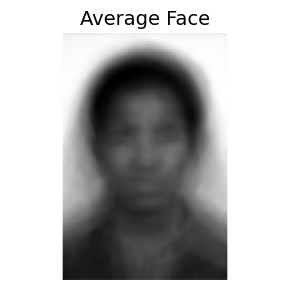

In [3]:
# Average over the third axis (the image index)
AvgFace = np.mean(pics[:, :, :mpic], axis=2)

plt.figure(figsize=(3, 3))
plt.pcolormesh(AvgFace, shading='gouraud', cmap='gray')
plt.axis('equal')
plt.axis('off')
plt.title('Average Face', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Display All Training Faces

A quick visual check of the full dataset. Images are arranged in a square grid.

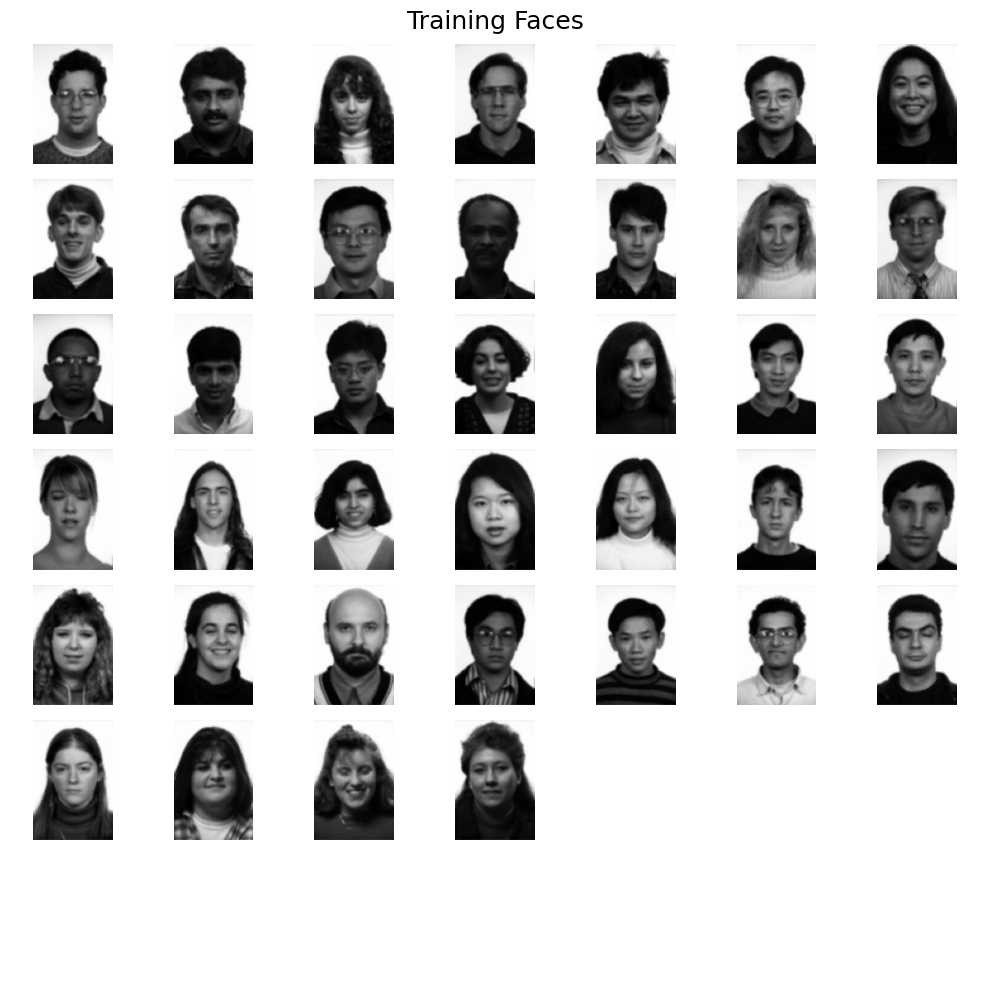

In [4]:
ncols = int(np.ceil(np.sqrt(mpictot)))

fig1, axes = plt.subplots(ncols, ncols, figsize=(10, 10))
axes = axes.flatten()

for i in range(len(axes)):
    ax = axes[i]
    if i < mpic:
        ax.pcolormesh(pics[:, :, i], shading='gouraud', cmap='gray')
        ax.set_aspect('equal')
    ax.axis('off')

fig1.suptitle('Training Faces', fontsize=18)
plt.tight_layout()
plt.show()

## 5. Build the Data Matrix and Covariance Matrix

Each face image is **flattened into a column vector** of length `mpixel`, forming the data matrix $A$ of shape `(mpixel, mpic)`.

The **covariance matrix** is then:

$$C = \frac{1}{N} A A^T$$

where $N$ is the number of training images. Note that $C$ has dimension `(mpixel × mpixel)`, which can be very large for high-resolution images — for a 100×100 image that is a 10,000 × 10,000 matrix.

> **Computational note:** For datasets where the number of images $N$ is much smaller than the number of pixels $p$, a more efficient approach works with the smaller $N \times N$ matrix $A^T A$ and recovers the eigenvectors of $AA^T$ from it. Here we use the direct approach for clarity.

In [5]:
# Flatten each training image into a column of A
A = np.zeros((mpixel, mpic))
for i in range(mpic):
    A[:, i] = pics[:, :, i].reshape(mpixel)

# Covariance matrix
C = np.matmul(A, A.T) / mpic

print('Data matrix A shape      :', A.shape)
print('Covariance matrix C shape:', C.shape)

Data matrix A shape      : (6144, 39)
Covariance matrix C shape: (6144, 6144)


## 6. Eigendecomposition — Finding the Eigenfaces

We compute the **eigenvectors and eigenvalues** of the symmetric covariance matrix $C$.

- `numpy.linalg.eigh` is used because $C$ is real symmetric; it guarantees real eigenvalues and orthonormal eigenvectors and is faster than the general `eig`.
- `eigh` returns eigenvalues in **ascending** order, so we reverse them to go from largest to smallest.
- Each eigenvector (column of $U$) is an **eigenface** — a basis image that captures a mode of variation across the training set. The eigenvalue associated with each eigenface indicates how much variance it explains.

In [6]:
# eigh returns eigenvalues in ascending order
D, U = np.linalg.eigh(C)

# Reverse so eigenvalues (and corresponding eigenvectors) are in descending order
D = D[::-1]
U = U[:, ::-1]

# Fraction of total variance explained by each eigenface
variance_explained = D / D.sum()

print(f'Top-5 eigenvalues  : {D[:5]}')
print(f'Variance explained : {variance_explained[:5].round(4)}')
print(f'Cumulative (top-5) : {variance_explained[:5].cumsum().round(4)}')

Top-5 eigenvalues  : [1930.42013733   85.87719077   57.47365294   30.62408667   24.81812727]
Variance explained : [0.8461 0.0376 0.0252 0.0134 0.0109]
Cumulative (top-5) : [0.8461 0.8837 0.9089 0.9223 0.9332]


## 7. Display the Eigenfaces

Each eigenface is reshaped back to `(row, col)` and displayed as an image. The **first few eigenfaces** capture the most variance and often look like blurry, abstract "ghost faces". Later eigenfaces capture finer, less common variations.

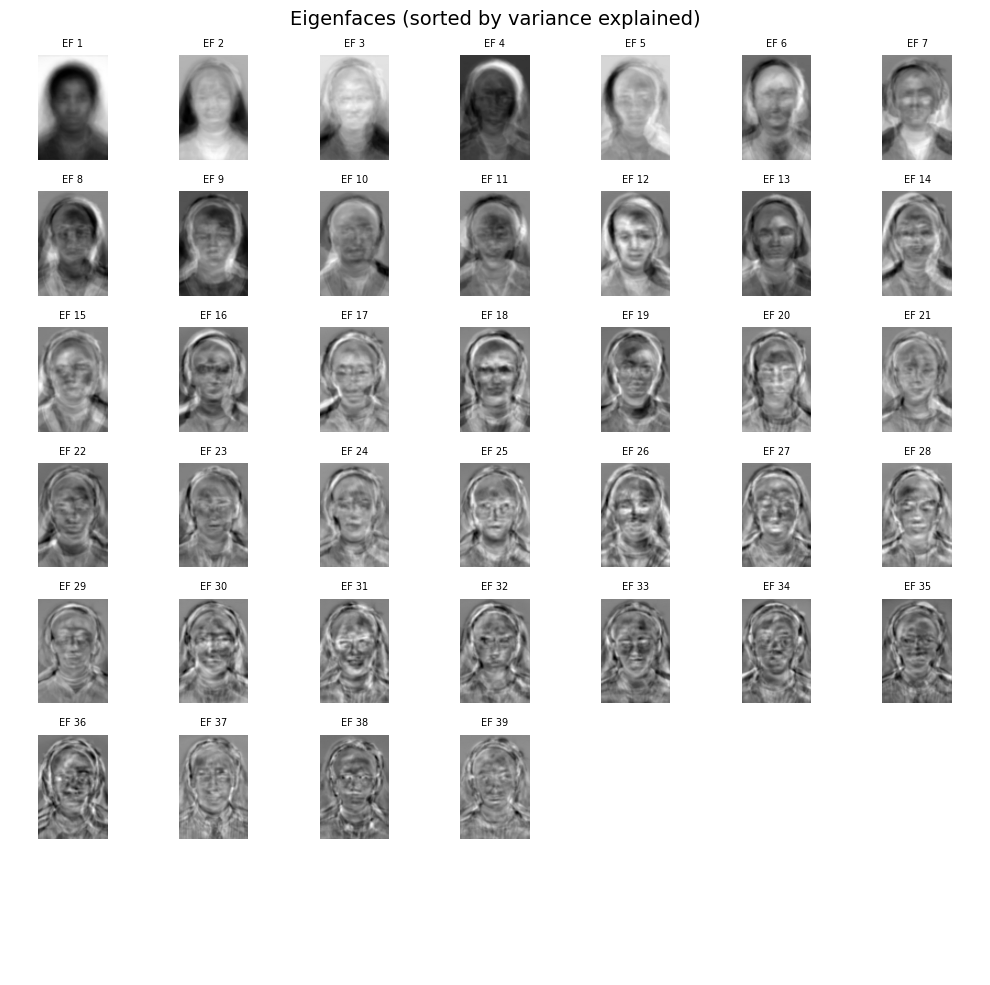

In [7]:
ncols_ef = int(np.ceil(np.sqrt(mpic)))

fig2, axes2 = plt.subplots(ncols_ef, ncols_ef, figsize=(10, 10))
axes2 = axes2.flatten()

for i in range(len(axes2)):
    ax = axes2[i]
    if i < mpic:
        img = U[:, i].reshape(row, col)
        ax.pcolormesh(img, shading='gouraud', cmap='gray')
        ax.set_aspect('equal')
        ax.set_title(f'EF {i+1}', fontsize=7)
    ax.axis('off')

fig2.suptitle('Eigenfaces (sorted by variance explained)', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Reconstruct a Face from Eigenfaces

Any face $\mathbf{f}$ can be approximated as:

$$\mathbf{f} \approx \bar{\mathbf{f}} + \sum_{k=1}^{K} \omega_k \, \mathbf{u}_k$$

where $\bar{\mathbf{f}}$ is the mean face, $\mathbf{u}_k$ are eigenfaces, and the **weights** (projections onto each eigenface) are:

$$\omega_k = \mathbf{u}_k^T (\mathbf{f} - \bar{\mathbf{f}})$$

We test this on the held-out image, varying how many eigenfaces $K$ are used, to see how reconstruction quality improves.

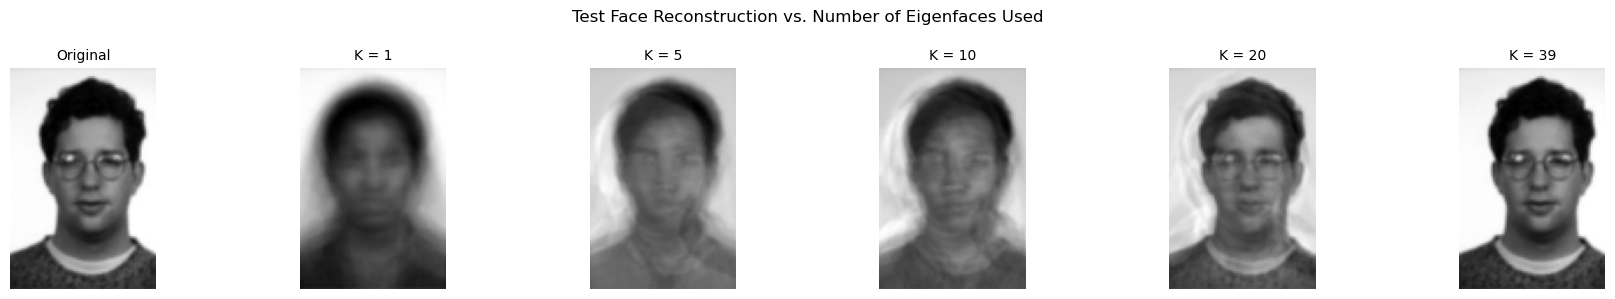

In [14]:
# Flatten the test face and subtract the mean
mface = 0 # index of the test face
test_face       = pics[:, :, mface].reshape(mpixel)
avg_face_flat   = AvgFace.reshape(mpixel)
test_face_norm  = test_face - avg_face_flat

# Project onto all eigenfaces to get the weight vector
weights = U.T @ test_face_norm          # shape: (mpixel,)

# Try reconstructing with K = 1, 5, 10, 20, mpic eigenfaces
K_values = [1, 5, 10, 20, mpic]
n_panels = len(K_values) + 1            # +1 for the original

fig3, axes3 = plt.subplots(1, n_panels, figsize=(3 * n_panels, 3))

# Original test face
axes3[0].pcolormesh(pics[:, :, mface], shading='gouraud', cmap='gray')
axes3[0].set_title('Original', fontsize=10)
axes3[0].axis('off')
axes3[0].set_aspect('equal')

for ax, K in zip(axes3[1:], K_values):
    reconstruction = avg_face_flat + U[:, :K] @ weights[:K]
    ax.pcolormesh(reconstruction.reshape(row, col), shading='gouraud', cmap='gray')
    ax.set_title(f'K = {K}', fontsize=10)
    ax.axis('off')
    ax.set_aspect('equal')

fig3.suptitle('Test Face Reconstruction vs. Number of Eigenfaces Used', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Reconstruction Error vs. Number of Eigenfaces

We can quantify how well a face is reconstructed by computing the **root mean square error (RMSE)** between the original and reconstructed pixel values as a function of $K$.

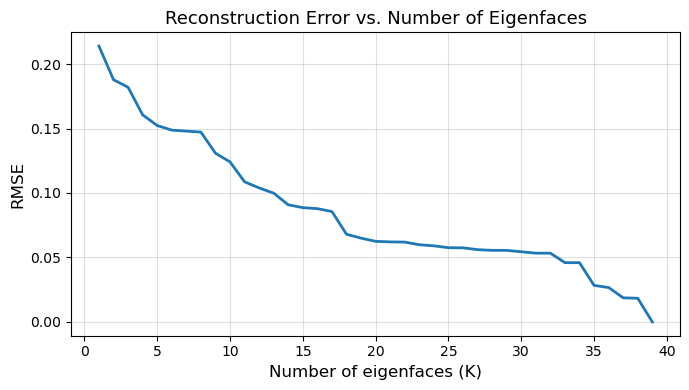

In [11]:
K_range = np.arange(1, mpic + 1)
rmse    = np.zeros(len(K_range))

for idx, K in enumerate(K_range):
    recon      = avg_face_flat + U[:, :K] @ weights[:K]
    rmse[idx]  = np.sqrt(np.mean((test_face - recon) ** 2))

plt.figure(figsize=(7, 4))
plt.plot(K_range, rmse, lw=2)
plt.xlabel('Number of eigenfaces (K)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Reconstruction Error vs. Number of Eigenfaces', fontsize=13)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()